## **Assessment of per SMRT cell contribution in master transcriptome** 

In [3]:
# To check which python software is being used 
import sys
print(sys.executable)
print(sys.version)

/lustre/home/vs455/.conda/envs/isoseq_tools/bin/python
3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]


In [4]:
# Import required packages  
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Per SMRT cell processing - QC report** <br>
Looking through the SMRT cell processing QC summary 

In [13]:
# Load the data
df_qc = pd.read_csv("/lustre/projects/Research_Project-193495/IsoSeqProcessed/SMRTcell_QC_summary.tsv", sep="\t")

df_qc.head()

,SMRT_cell_ID,ZMWs_input,ZMWs_passing_CCS,ZMWs_passing_CCS(%),ZMWs_failing_CCS,ZMWs_failing_CCS(%),Failed_CCS_lacking_full_passes,Failed_CCS_lacking_full_passes(%),Failed_CCS_below_min_RQ,Failed_CCS_below_min_RQ(%),FL_reads,FLNC_reads,FLNC_rate_(%),FLNC+polyA_reads,FLNC+polyA_(%)
0,m54082_180606_210950,775613,368479,47.51,407134,52.49,281869,69.23,63157,15.51,262942,258370,33.31,257965,33.26
1,m54082_180815_111944,526174,362886,68.97,163288,31.03,112748,69.05,29370,17.99,300241,291432,55.39,291010,55.31
2,m54082_180817_142929,641300,370756,57.81,270544,42.19,183237,67.73,48897,18.07,312789,310100,48.35,309716,48.30
3,m54082_181216_092744,695943,409369,58.82,286574,41.18,170861,59.62,56360,19.67,345847,337691,48.52,337328,48.47
4,m54082_181217_054735,712501,440393,61.81,272108,38.19,162284,59.64,52049,19.13,368681,364888,51.21,364558,51.17


In [11]:
print(df_qc.columns)

Index(['SMRT_cell_ID', 'ZMWs_input', 'ZMWs_passing_CCS', 'ZMWs_passing_CCS(%)',
       'ZMWs_failing_CCS', 'ZMWs_failing_CCS(%)',
       'Failed_CCS_lacking_full_passes', 'Failed_CCS_lacking_full_passes(%)',
       'Failed_CCS_below_min_RQ', 'Failed_CCS_below_min_RQ(%)', 'FL_reads',
       'FLNC_reads', 'FLNC_rate_(%)', 'FLNC+polyA_reads', 'FLNC+polyA_(%)'],
      dtype='object')


**Summary of the QC metrics**

In [14]:
# Select relevant columns 
qc_cols = [
    'ZMWs_passing_CCS(%)',
    'ZMWs_failing_CCS(%)',
    'Failed_CCS_lacking_full_passes(%)',
    'Failed_CCS_below_min_RQ(%)',
    'FLNC_rate_(%)',
    'FLNC+polyA_(%)'
    ]

qc_summary = df_qc[qc_cols].describe().round(2)
qc_summary

,ZMWs_passing_CCS(%),ZMWs_failing_CCS(%),Failed_CCS_lacking_full_passes(%),Failed_CCS_below_min_RQ(%),FLNC_rate_(%),FLNC+polyA_(%)
count,34.00,34.00,34.00,34.00,34.00,34.00
mean,74.57,25.43,67.72,13.80,60.52,60.40
std,9.16,9.16,4.07,2.57,8.22,8.18
min,47.51,9.37,59.62,9.31,33.31,33.26
25%,70.40,20.19,64.85,11.98,56.14,56.08
50%,75.60,24.40,68.07,13.91,61.07,60.92
75%,79.81,29.60,69.41,14.79,64.57,64.37
max,90.63,52.49,76.32,19.67,73.58,73.36


**Looking at number of final FLNC transcript generated after QC** <br>
This is the number of FLNC contribution per SMRT cell before merging data together and clustering similar transcripts 

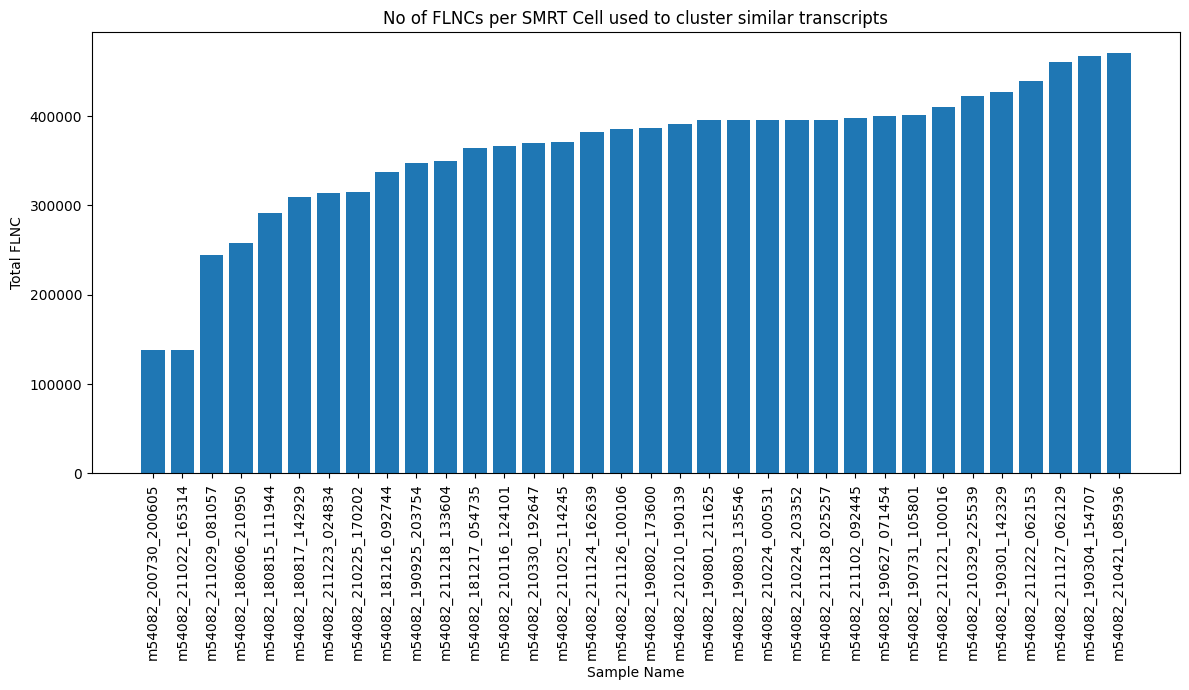

In [15]:
# Sort values 
df_flnc_sorted = df_qc.sort_values('FLNC+polyA_reads')

plt.figure(figsize=(12,7))

plt.bar(
    df_flnc_sorted['SMRT_cell_ID'],
    df_flnc_sorted['FLNC+polyA_reads']
)

plt.xlabel("Sample Name")
plt.ylabel("Total FLNC")
plt.title("No of FLNCs per SMRT Cell used to cluster similar transcripts")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [22]:
# Get summary of spread 
bins = [100000, 200000, 300000, 400000, 470000]
labels = ['100k–200k', '200k–300k', '300k–400k', '400k–470k']


df_qc['FLNC_bin'] = pd.cut(
    df_qc['FLNC+polyA_reads'],
    bins=bins,
    labels=labels)

table = df_qc['FLNC_bin'].value_counts().sort_index().reset_index()
table.columns = ['FLNC Range', 'Number of SMRT Cells']

table

,FLNC Range,Number of SMRT Cells
0,100k–200k,2
1,200k–300k,3
2,300k–400k,21
3,400k–470k,7


The five SMRT cells with lower FLNCs are all CONTROL samples. 4 of them are from the Maudsley study, 1 from Montreal (_200605). <br>
The SMRT cells with the higer FLNCs are varied samples. 

### **per SMRT cell QC of master transcriptome / isoform classification** <br>

Looking at per SMRT cell isoform classification when comparing with GENCODE and in-house ONT annotations   

In [5]:
# Load JSON report file (output of pigeon isoform classification + filter step)
Isoform_gencode = "/lustre/projects/Research_Project-193495/MasterTranscriptome_v2/Annotation/gencode_v48/collapsed_classification.filtered.report.json"
Isoform_ont = "/lustre/projects/Research_Project-193495/MasterTranscriptome_v2/Annotation/exeter_ont/collapsed_classification.filtered.report.json"

**A. Against GENCODE annotation**

In [25]:
# Read in the file 
with open(Isoform_gencode) as f:
    data = json.load(f)

table = data["tables"][0]

df_gencode = pd.DataFrame({
    col["header"]: col["values"]
    for col in table["columns"]
})

df_gencode.head()

,Sample Name,Total Unique Genes,"Total Unique Genes, known genes only",Total Unique Transcripts,"Total Unique Transcripts, known transcripts only","Total Unique Transcripts, novel transcripts > 1 TPM",FLNC Reads Mapped to Genome,FLNC Reads Confidently Mapped to Transcriptome,"FLNC Reads Confidently Mapped to Transcriptome, excluding ribomito",Transcripts classified as Full-splice Matches (FSM),Transcripts classified as Incomplete-splice Matches (ISM),Transcripts classified as Novel In Catalog (NIC),Transcripts classified as Novel Not In Catalog (NNC),Percent of reads classified as Full-splice Matches (FSM),Percent of reads classified as Incomplete-splice Matches (ISM),Percent of reads classified as Novel In Catalog (NIC),Percent of reads classified as Novel Not In Catalog (NNC)
0,SMRT_m54082_180606_210950,12700,12655,35491,20677,14814,143732,143206,131774,23844,15162,8532,5829,72.38,13.40,8.42,5.43
1,SMRT_m54082_180815_111944,12465,12380,34624,20856,13768,135630,135118,128416,21398,21092,7334,5982,64.60,21.85,7.58,5.59
2,SMRT_m54082_180817_142929,12992,12913,37678,21403,16275,177900,177269,169227,24711,17140,9162,6587,72.88,13.23,8.11,5.42
3,SMRT_m54082_181216_092744,9558,9536,18810,13962,4848,85517,85331,61451,12606,9572,2566,2117,77.24,14.52,3.68,4.35
4,SMRT_m54082_181217_054735,10699,10624,25324,17633,7691,143117,142747,94622,15542,17427,4320,3035,74.49,18.46,3.84,2.95


**1. Per SMRT cell contribution of total unique genes and transcripts**

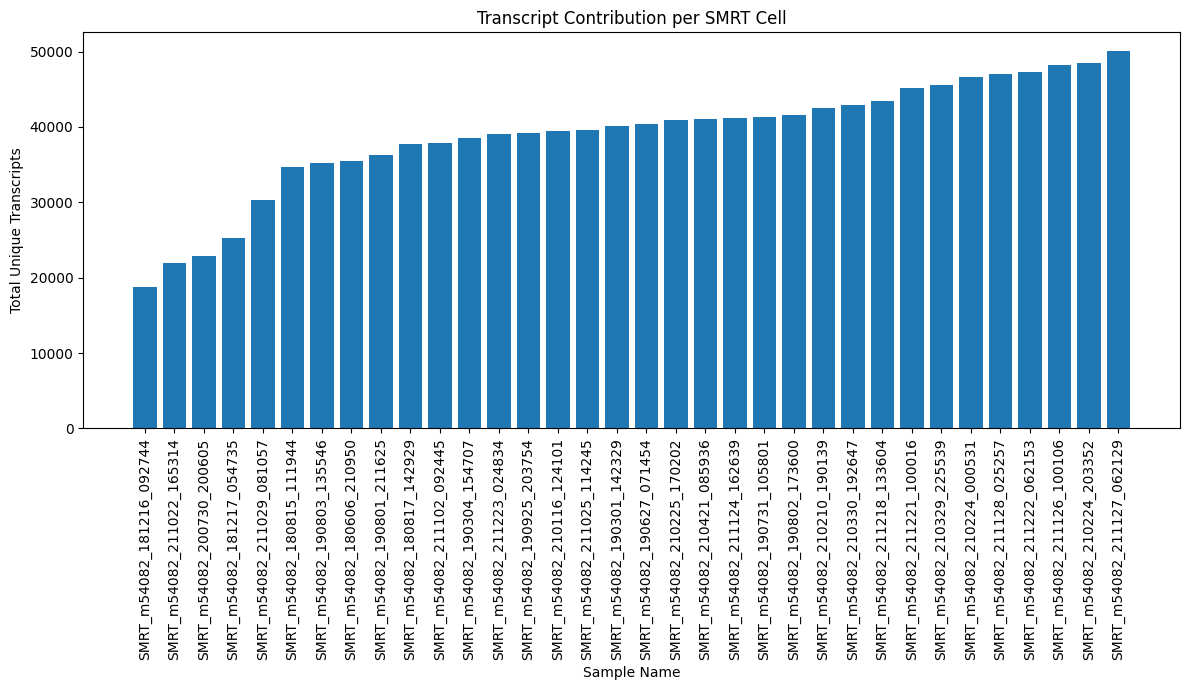

In [26]:
# Sort values 
df_gencode_sorted = df_gencode.sort_values('Total Unique Transcripts')

plt.figure(figsize=(12,7))

plt.bar(
    df_gencode_sorted['Sample Name'],
    df_gencode_sorted['Total Unique Transcripts']
)

plt.xlabel("Sample Name")
plt.ylabel("Total Unique Transcripts")
plt.title("Transcript Contribution per SMRT Cell")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Contribution is fairly even across most SMRT cells<br>
Lowest few SMRT cells: ~19k–30k<br>
Bulk of cells: ~38k–45k<br>
Top cells: ~45k–50k<br>

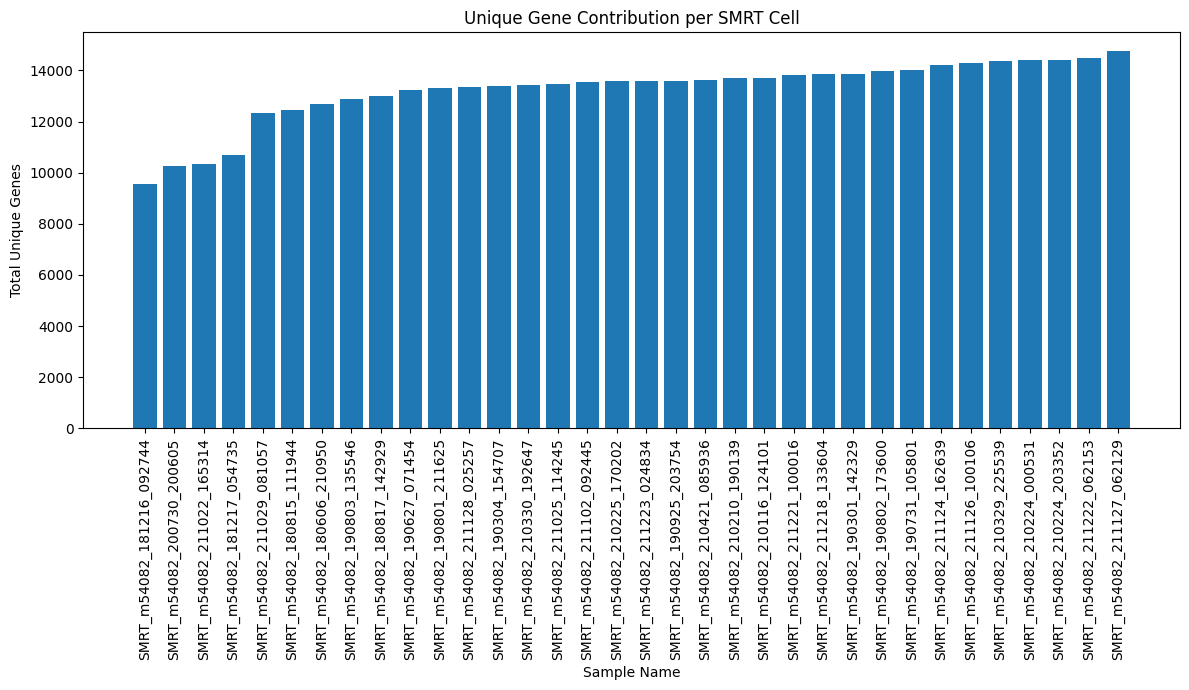

In [27]:
# Sort values 
df_gencode_sorted_genes = df_gencode.sort_values('Total Unique Genes')

plt.figure(figsize=(12,7))

plt.bar(
    df_gencode_sorted_genes['Sample Name'],
    df_gencode_sorted_genes['Total Unique Genes']
)

plt.xlabel("Sample Name")
plt.ylabel("Total Unique Genes")
plt.title("Unique Gene Contribution per SMRT Cell")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Similar trend when looking at per SMRT cell contribution of unique genes and unique transcripts. <Br>

Same 5 SMRT cells are in the lower end - all are CONTROL samples; 2 are twin study, 2 Maudsley, 1 Montreal <br>
And 3 of those also showed lower FLNC to start with (before collapsing transcripts)
<br>
Only 1 of the 5 SMRT cells are reruns..... <Br>

<Br>
But is the no of transcript contribution mainly due to read depth? 

**2. Read depth**

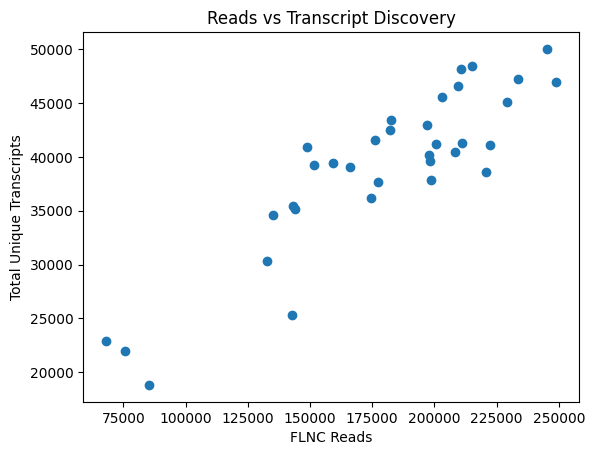

In [28]:
# Scatterplot comparing read depth with unique transcript contribution 
plt.scatter(
    df_gencode['FLNC Reads Confidently Mapped to Transcriptome'],
    df_gencode['Total Unique Transcripts']
)

plt.xlabel("FLNC Reads")
plt.ylabel("Total Unique Transcripts")
plt.title("Reads vs Transcript Discovery")
plt.show()


Fairly linear. The variation we see with unique transcript contribution is mostly explained by read depth 
<br> <br> Rough breakdown:<br>
Lower reads (~70–100k) → ~18–23k transcripts<br>
Mid reads (~150–200k) → ~35–43k transcripts<br>
Higher reads (~220–250k) → ~45–50k transcripts<br>

**Distribution of isoform classification across SMRT cells**

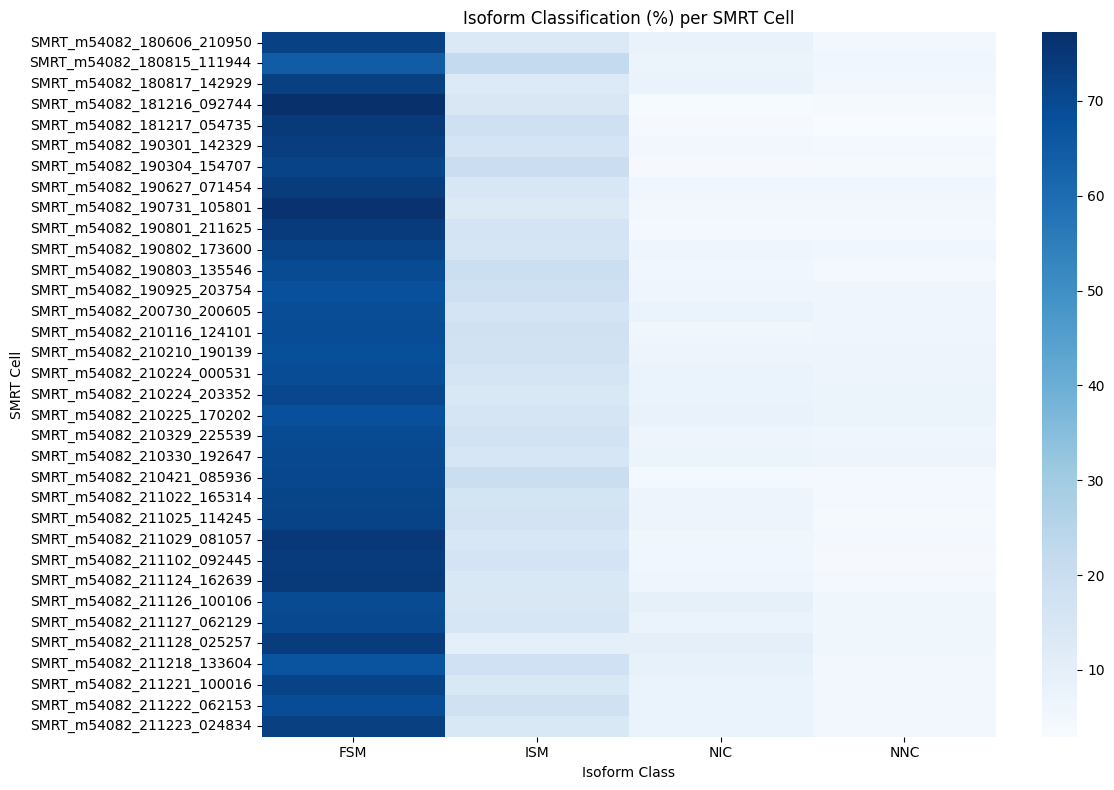

In [31]:
# Extract relevant columns 
cols_pct = [
    'Percent of reads classified as Full-splice Matches (FSM)',
    'Percent of reads classified as Incomplete-splice Matches (ISM)',
    'Percent of reads classified as Novel In Catalog (NIC)',
    'Percent of reads classified as Novel Not In Catalog (NNC)'
]

df_heat = df_gencode.set_index('Sample Name')[cols_pct]

# Rename columns
df_heat = df_heat.rename(columns={
    'Percent of reads classified as Full-splice Matches (FSM)': 'FSM',
    'Percent of reads classified as Incomplete-splice Matches (ISM)': 'ISM',
    'Percent of reads classified as Novel In Catalog (NIC)': 'NIC',
    'Percent of reads classified as Novel Not In Catalog (NNC)': 'NNC'
})


plt.figure(figsize=(12,8))
sns.heatmap(df_heat, cmap='Blues')

plt.title("Isoform Classification (%) per SMRT Cell")
plt.xlabel("Isoform Class")
plt.ylabel("SMRT Cell")

plt.tight_layout()
plt.show()


In [32]:
# Quick summary of isoform classification 
summary = df_gencode[cols_pct].describe().round(2)

summary

,Percent of reads classified as Full-splice Matches (FSM),Percent of reads classified as Incomplete-splice Matches (ISM),Percent of reads classified as Novel In Catalog (NIC),Percent of reads classified as Novel Not In Catalog (NNC)
count,34.00,34.00,34.00,34.00
mean,71.36,16.05,6.77,5.47
std,2.73,2.38,1.61,1.00
min,64.60,9.83,3.68,2.95
25%,69.39,14.38,5.78,4.86
50%,71.71,16.04,6.90,5.48
75%,73.48,17.62,7.86,6.14
max,77.24,21.85,10.07,7.32


A subset of SMRT cells consistently shows reduced numbers of detected genes and transcripts, which is explained by lower sequencing depth rather than differences in transcriptome composition. These cells exhibit similar isoform classification patterns to higher-depth runs, indicating that they are technically sound but under-sequenced rather than biologically distinct.

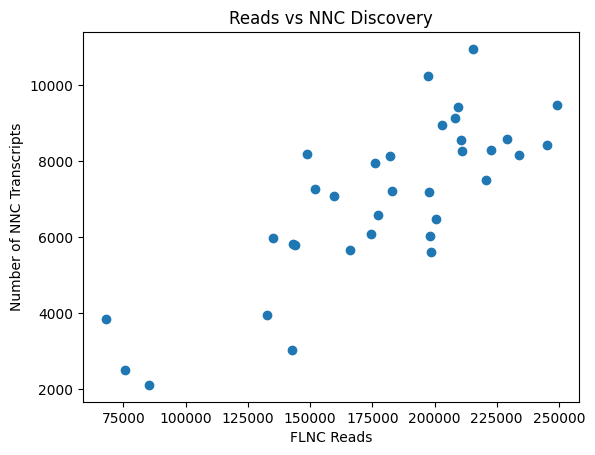

In [33]:
# Number of reads vs NNC isoform classification 
plt.scatter(
    df_gencode['FLNC Reads Confidently Mapped to Transcriptome'],
    df_gencode['Transcripts classified as Novel Not In Catalog (NNC)']
)

plt.xlabel("FLNC Reads")
plt.ylabel("Number of NNC Transcripts")
plt.title("Reads vs NNC Discovery")
plt.show()

**B. Against in-house ONT annotation**

In [34]:
# Read in the file 
with open(Isoform_ont) as f:
    data = json.load(f)

table = data["tables"][0]

df_ont = pd.DataFrame({
    col["header"]: col["values"]
    for col in table["columns"]
})

df_ont.head()

,Sample Name,Total Unique Genes,"Total Unique Genes, known genes only",Total Unique Transcripts,"Total Unique Transcripts, known transcripts only","Total Unique Transcripts, novel transcripts > 1 TPM",FLNC Reads Mapped to Genome,FLNC Reads Confidently Mapped to Transcriptome,"FLNC Reads Confidently Mapped to Transcriptome, excluding ribomito",Transcripts classified as Full-splice Matches (FSM),Transcripts classified as Incomplete-splice Matches (ISM),Transcripts classified as Novel In Catalog (NIC),Transcripts classified as Novel Not In Catalog (NNC),Percent of reads classified as Full-splice Matches (FSM),Percent of reads classified as Incomplete-splice Matches (ISM),Percent of reads classified as Novel In Catalog (NIC),Percent of reads classified as Novel Not In Catalog (NNC)
0,SMRT_m54082_180606_210950,6427,4723,54571,32302,22269,156713,148306,148306,38057,9936,4311,11881,69.76,7.97,4.60,12.30
1,SMRT_m54082_180815_111944,6793,4713,56991,35075,21916,162490,153596,153596,42212,14694,3980,11235,66.78,12.66,4.15,10.94
2,SMRT_m54082_180817_142929,6996,4835,57060,33197,23863,195217,184908,184908,39099,11602,4864,12252,70.41,8.10,4.77,11.44
3,SMRT_m54082_181216_092744,5750,4895,35387,28271,7116,86657,84639,84639,30502,7477,1459,3754,77.49,11.43,2.52,6.23
4,SMRT_m54082_181217_054735,6578,4739,50341,38264,12077,151791,147035,147035,48604,13301,2632,5446,75.56,13.38,2.57,5.35


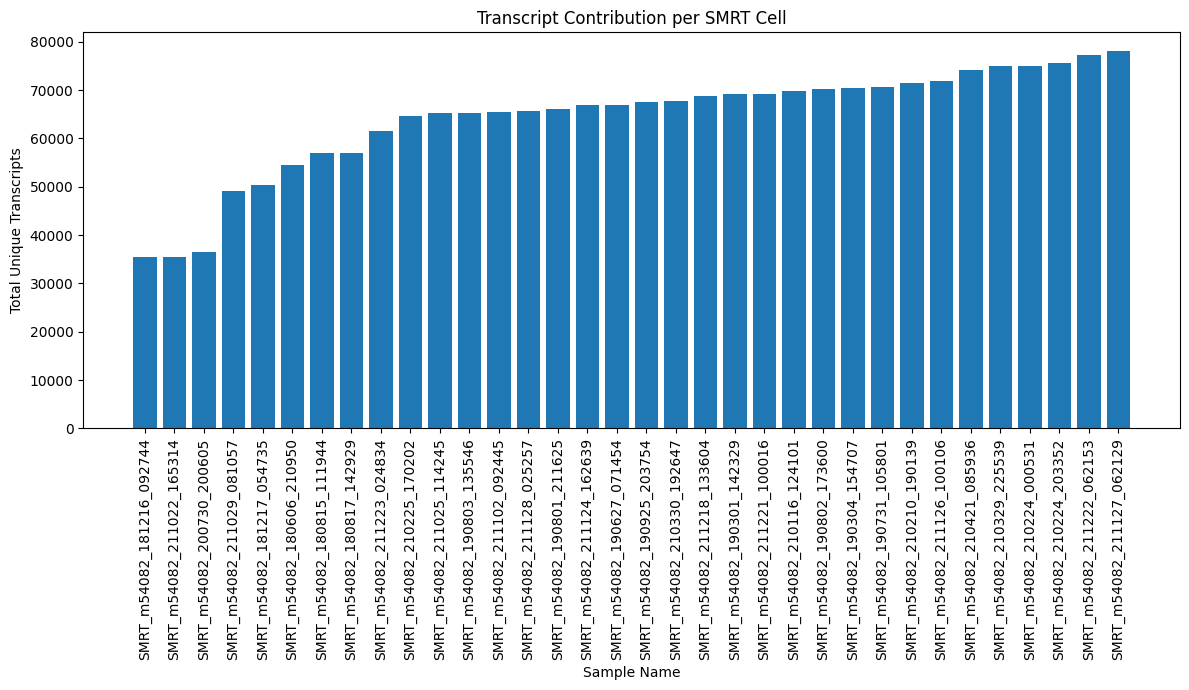

In [35]:
# Sort values 
df_ont_sorted = df_ont.sort_values('Total Unique Transcripts')

plt.figure(figsize=(12,7))

plt.bar(
    df_ont_sorted['Sample Name'],
    df_ont_sorted['Total Unique Transcripts']
)

plt.xlabel("Sample Name")
plt.ylabel("Total Unique Transcripts")
plt.title("Transcript Contribution per SMRT Cell")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Same 5 SMRT cells on the lower end of the unique transcript contribution <br>
What about read depth? 

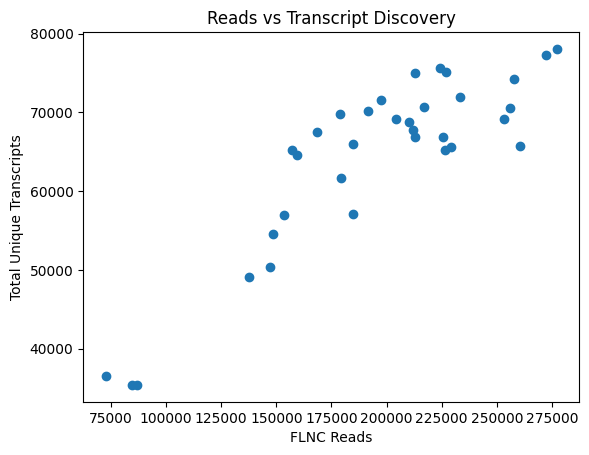

In [36]:
# Scatterplot comparing read depth with unique transcript contribution 
plt.scatter(
    df_ont['FLNC Reads Confidently Mapped to Transcriptome'],
    df_ont['Total Unique Transcripts']
)

plt.xlabel("FLNC Reads")
plt.ylabel("Total Unique Transcripts")
plt.title("Reads vs Transcript Discovery")
plt.show()

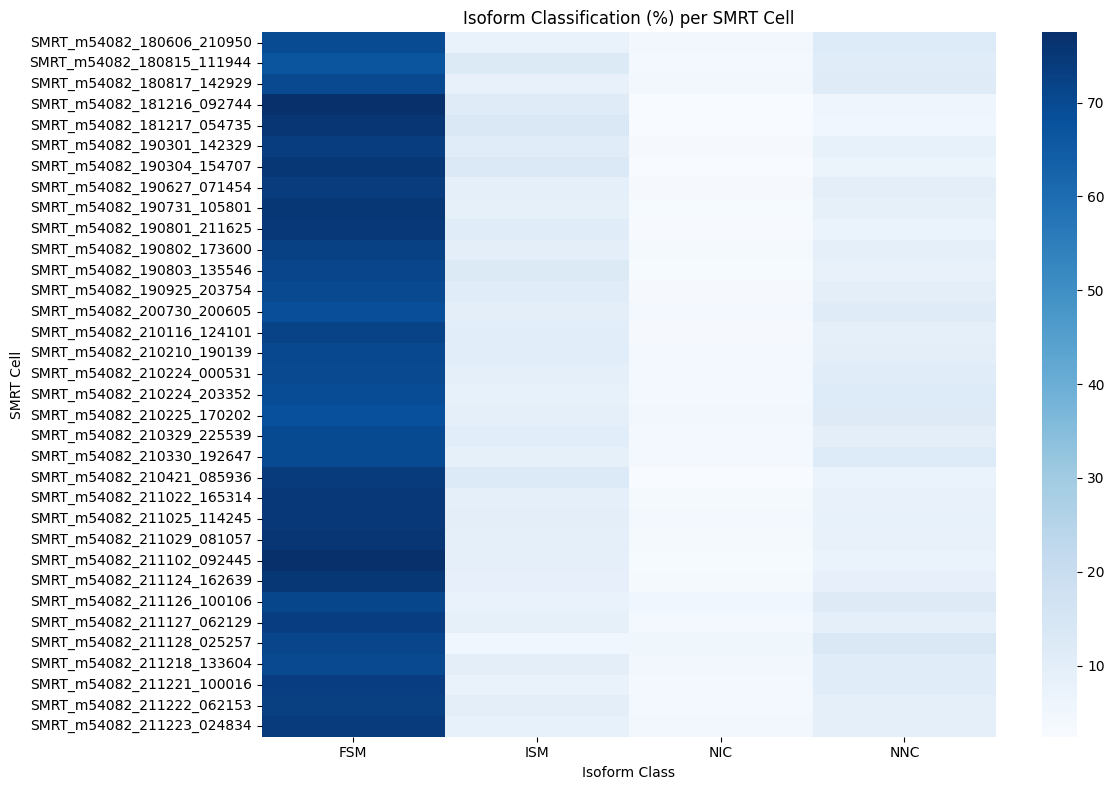

In [37]:
# Extract relevant columns 
cols_pct = [
    'Percent of reads classified as Full-splice Matches (FSM)',
    'Percent of reads classified as Incomplete-splice Matches (ISM)',
    'Percent of reads classified as Novel In Catalog (NIC)',
    'Percent of reads classified as Novel Not In Catalog (NNC)'
]

df_heat = df_ont.set_index('Sample Name')[cols_pct]

# Rename columns
df_heat = df_heat.rename(columns={
    'Percent of reads classified as Full-splice Matches (FSM)': 'FSM',
    'Percent of reads classified as Incomplete-splice Matches (ISM)': 'ISM',
    'Percent of reads classified as Novel In Catalog (NIC)': 'NIC',
    'Percent of reads classified as Novel Not In Catalog (NNC)': 'NNC'
})


plt.figure(figsize=(12,8))
sns.heatmap(df_heat, cmap='Blues')

plt.title("Isoform Classification (%) per SMRT Cell")
plt.xlabel("Isoform Class")
plt.ylabel("SMRT Cell")

plt.tight_layout()
plt.show()

Same pattern as we saw earlier, only a slight increase in the NNC category 

In [38]:
# Quick summary of isoform classification 
summary = df_ont[cols_pct].describe().round(2)

summary

,Percent of reads classified as Full-splice Matches (FSM),Percent of reads classified as Incomplete-splice Matches (ISM),Percent of reads classified as Novel In Catalog (NIC),Percent of reads classified as Novel Not In Catalog (NNC)
count,34.00,34.00,34.00,34.00
mean,72.53,9.91,3.87,9.68
std,2.67,1.75,0.75,1.96
min,66.78,5.18,2.43,5.35
25%,70.31,8.94,3.34,8.28
50%,72.72,9.76,3.96,9.70
75%,74.96,10.93,4.40,11.12
max,77.49,13.38,5.46,13.51
